# RNN & LSTM

## Step 1 : Download Dataset

In [ ]:
!pip install yfinance

In [ ]:
#Import libraries

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [ ]:
#Import Datasets

TICKER = "GOOGL"
START = "2010-01-01"
END = "2020-01-01"  # exclusive akhir, supaya data 2019 penuh

print(f"Downloading {TICKER} data from {START} to {END} ...")
df = yf.download(TICKER, start=START, end=END, auto_adjust=False)
df = df[['Close']].copy()  # gunakan harga Close sebagai target
df.dropna(inplace=True)

print(df.shape)
print(df.head())
print(df.tail())

[*********************100%***********************]  1 of 1 completed

(2516, 1)
Price           Close
Ticker          GOOGL
Date                 
2010-01-04  15.684434
2010-01-05  15.615365
2010-01-06  15.221722
2010-01-07  14.867367
2010-01-08  15.065566
Price           Close
Ticker          GOOGL
Date                 
2019-12-24  67.221497
2019-12-26  68.123497
2019-12-27  67.732002
2019-12-30  66.985497
2019-12-31  66.969498


In [ ]:
yf.download(TICKER, start=START, end=END, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,,
2010-01-04,15.546578,15.684434,15.753504,15.621622,15.689439,78169752
2010-01-05,15.478118,15.615365,15.711712,15.554054,15.695195,120067812
2010-01-06,15.087933,15.221722,15.662162,15.174174,15.662162,158988852
2010-01-07,14.736694,14.867367,15.265265,14.831081,15.250250,256315428
2010-01-08,14.933149,15.065566,15.096346,14.742492,14.814815,188783028
...,...,...,...,...,...,...
2019-12-24,66.630669,67.221497,67.600502,67.208504,67.510498,13468000
2019-12-26,67.524734,68.123497,68.160004,67.275497,67.327499,23662000


Berikut terlampir harga Mendekati tutup, harga tutup hari, harga tertinggi, harga terendah, harga buka, dan volume transaksi dari google setiap harinya dari tanggal 1 Januari 2010 sampai dengan 31 Desember 2019.

## Step 2 : Split Train and Test Set


Train shape: (2264, 1)  (2010-01-04 00:00:00 - 2018-12-31 00:00:00)
Val shape  : (252, 1)  (2019-01-02 00:00:00 - 2019-12-31 00:00:00)
Proporsi train: 90.0%  |  val: 10.0%


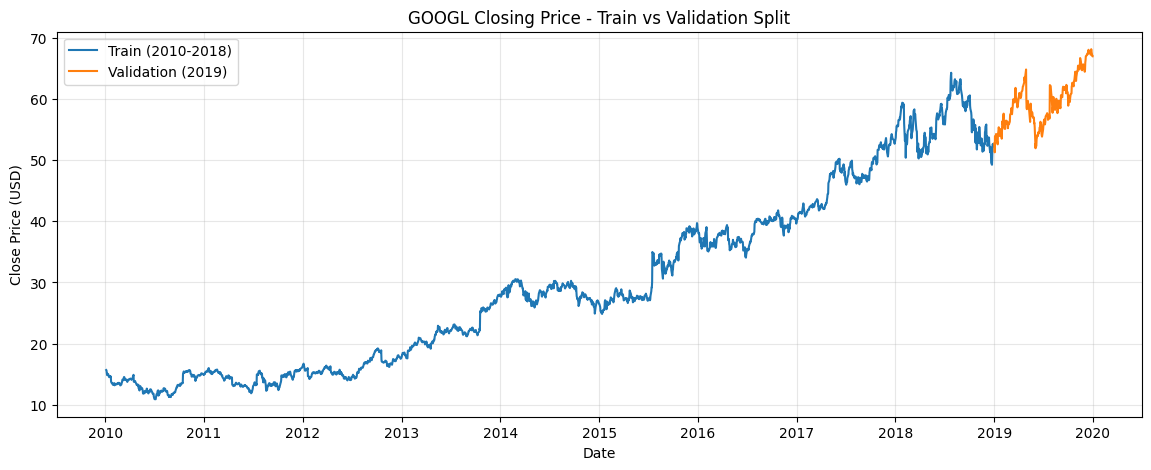

In [ ]:
#Split the dataset into train and validation

train_df = df.loc[:'2018-12-31']
val_df   = df.loc['2019-01-01':]

print(f"\nTrain shape: {train_df.shape}  ({train_df.index.min()} - {train_df.index.max()})")
print(f"Val shape  : {val_df.shape}  ({val_df.index.min()} - {val_df.index.max()})")
print(f"Proporsi train: {len(train_df)/len(df)*100:.1f}%  |  val: {len(val_df)/len(df)*100:.1f}%")

# Plot raw data untuk melihat pola & kualitas data
plt.figure(figsize=(14,5))
plt.plot(train_df.index, train_df['Close'], label='Train (2010-2018)')
plt.plot(val_df.index, val_df['Close'], label='Validation (2019)')
plt.title(f'{TICKER} Closing Price - Train vs Validation Split')
plt.xlabel('Date'); plt.ylabel('Close Price (USD)')
plt.legend(); plt.grid(alpha=0.3)

Dibagi data train dan validation

Train : 1 Januari 2010 - 31 Desember 2018

Validasi : 1 Januari 2019 - 31 Desember 2019.

In [ ]:
train_df

Price,Close
Ticker,GOOGL
Date,
2010-01-04,15.684434
2010-01-05,15.615365
2010-01-06,15.221722
2010-01-07,14.867367
2010-01-08,15.065566
...,...
2018-12-24,49.233501
2018-12-26,52.392502


In [ ]:
# Feature Scaling

scaler = StandardScaler()
train_data = scaler.fit_transform(train_df)
val_data = scaler.transform(val_df)
print(train_data.shape)
print(val_data.shape)

(2264, 1)
(252, 1)


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df.values)          # fit_transform di train
# Untuk val, kita butuh 60 hari terakhir dari TRAIN sebagai "warm-up window"
# supaya prediksi val dimulai dari kondisi yang kontinu dengan train
full_data = pd.concat([train_df, val_df])
inputs = full_data[len(full_data) - len(val_df) - 60:].values
inputs_scaled = scaler.transform(inputs)                      # transform saja (pakai scaler dari train)

In [ ]:
TIMESTEP_1 = 60
TIMESTEP_2 = 90

def create_dataset(data, timestep=60):
    X, y = [], []
    for i in range(timestep, len(data)):
        X.append(data[i-timestep:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_60, y_train_60 = create_dataset(train_scaled, TIMESTEP_1)
X_val_60, y_val_60 = create_dataset(inputs_scaled, TIMESTEP_1)

# Reshape ke [samples, timesteps, features] -> required shape untuk LSTM/RNN/GRU
X_train_60 = X_train_60.reshape(X_train_60.shape[0], X_train_60.shape[1], 1)
X_val_60 = X_val_60.reshape(X_val_60.shape[0], X_val_60.shape[1], 1)

print(f"\nX_train for timestamp 60 shape: {X_train_60.shape}, y_train for timestamp 60 shape: {y_train_60.shape}")
print(f"X_val for timestamp 60 shape  : {X_val_60.shape}, y_val for timestamp 60 shape  : {y_val_60.shape}")
6
X_train_90, y_train_90 = create_dataset(train_scaled, TIMESTEP_2)
X_val_90, y_val_90 = create_dataset(inputs_scaled, TIMESTEP_2)

# Reshape ke [samples, timesteps, features] -> required shape untuk LSTM/RNN/GRU
X_train_90 = X_train_90.reshape(X_train_90.shape[0], X_train_90.shape[1], 1)
X_val_90 = X_val_90.reshape(X_val_90.shape[0], X_val_90.shape[1], 1)

print(f"\nX_train for timestamp 90 shape: {X_train_90.shape}, y_train for timestamp 90 shape: {y_train_90.shape}")
print(f"X_val for timestamp 90 shape  : {X_val_90.shape}, y_val for timestamp 90 shape  : {y_val_90.shape}")


X_train for timestamp 60 shape: (2204, 60, 1), y_train for timestamp 60 shape: (2204,)
X_val for timestamp 60 shape  : (252, 60, 1), y_val for timestamp 60 shape  : (252,)

X_train for timestamp 90 shape: (2174, 90, 1), y_train for timestamp 90 shape: (2174,)
X_val for timestamp 90 shape  : (222, 90, 1), y_val for timestamp 90 shape  : (222,)


### Helper Function

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===== HELPER: PLOT HISTORY =====
def plot_history(history, title):
    """Plot training & validation loss per epoch."""
    fig, ax = plt.subplots(figsize=(12, 4))
    ep = range(1, len(history.history['loss']) + 1)
    ax.plot(ep, history.history['loss'],     'b-o', ms=3, lw=1.5, label='Train Loss')
    ax.plot(ep, history.history['val_loss'], 'r-o', ms=3, lw=1.5, label='Val Loss')
    ax.set_title(f'{title} — Training Loss', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('(','').replace(')','') + '_loss.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()


# ===== HELPER: EVALUASI & PLOT PREDIKSI =====
def evaluate_and_plot(model, X_val, y_val, scaler, history, model_name,
                      val_dates=None):
    """
    Evaluasi model dengan metrik regresi dan plot prediksi vs aktual.

    Metrik:
    - MAE  : Mean Absolute Error — rata-rata kesalahan absolut (dalam USD)
    - RMSE : Root Mean Square Error — penalti lebih besar untuk error besar
    - MAPE : Mean Absolute Percentage Error — kesalahan relatif (%)
    - R²   : Coefficient of Determination — seberapa baik model menjelaskan variansi
    """
    # Prediksi
    y_pred_scaled = model.predict(X_val, verbose=0)

    # Inverse transform ke skala asli (USD)
    y_true_usd = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_usd = scaler.inverse_transform(y_pred_scaled).flatten()

    # Hitung metrik
    mae  = mean_absolute_error(y_true_usd, y_pred_usd)
    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mape = np.mean(np.abs((y_true_usd - y_pred_usd) / y_true_usd)) * 100
    r2   = r2_score(y_true_usd, y_pred_usd)

    print("=" * 60)
    print(f"📊 EVALUASI: {model_name}")
    print("=" * 60)
    print(f"\n  MAE  : ${mae:.2f}    (rata-rata kesalahan absolut)")
    print(f"  RMSE : ${rmse:.2f}    (root mean squared error)")
    print(f"  MAPE : {mape:.2f}%    (kesalahan relatif rata-rata)")
    print(f"  R²   : {r2:.4f}     (1.0 = sempurna)")

    best_val_loss = min(history.history['val_loss'])
    n_epochs      = len(history.history['loss'])
    print(f"\n  Best Val Loss  : {best_val_loss:.6f}")
    print(f"  Epochs dilatih : {n_epochs}")

    # Plot prediksi vs aktual
    x_axis = val_dates if val_dates is not None else np.arange(len(y_true_usd))
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))

    # Full plot
    axes[0].plot(x_axis, y_true_usd, color='steelblue', lw=1.5,
                 label='Harga Aktual (USD)', alpha=0.9)
    axes[0].plot(x_axis, y_pred_usd, color='coral',     lw=1.5,
                 label='Harga Prediksi (USD)', alpha=0.9, linestyle='--')
    axes[0].fill_between(x_axis, y_true_usd, y_pred_usd,
                         alpha=0.2, color='orange', label='Error Area')
    axes[0].set_title(f'{model_name} — Prediksi vs Aktual (2019)',
                      fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Harga (USD)'); axes[0].legend(); axes[0].grid(alpha=0.3)
    mae_str = f"MAE=${mae:.2f}  RMSE=${rmse:.2f}  MAPE={mape:.2f}%  R²={r2:.4f}"
    axes[0].set_xlabel(mae_str, fontsize=10, labelpad=8)

    # Scatter actual vs predicted
    axes[1].scatter(y_true_usd, y_pred_usd, alpha=0.4, s=20, color='purple')
    mn = min(y_true_usd.min(), y_pred_usd.min()) * 0.98
    mx = max(y_true_usd.max(), y_pred_usd.max()) * 1.02
    axes[1].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel('Harga Aktual (USD)', fontsize=11)
    axes[1].set_ylabel('Harga Prediksi (USD)', fontsize=11)
    axes[1].set_title('Scatter: Aktual vs Prediksi', fontweight='bold', fontsize=12)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('(','').replace(')','') + '_pred.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()

    return {
        'name':  model_name,
        'mae':   mae,
        'rmse':  rmse,
        'mape':  mape,
        'r2':    r2,
        'best_val_loss': best_val_loss,
        'epochs': n_epochs,
        'y_true': y_true_usd,
        'y_pred': y_pred_usd
    }

# Ambil tanggal untuk sumbu X plot
val_dates = val_df.index

print("✅ Helper functions siap!")

✅ Helper functions siap!


## Step 3 : RNN Model Training

In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

### 3.1 Simple LSTM

In [ ]:
# ===== BUILD MODEL 1: SIMPLE LSTM =====
def build_model_1_lstm(timestep=TIMESTEP_1):
    model = Sequential([
        # ================================================
        # LSTM Layer 1 — return_sequences=True
        # Output: (batch, timestep, 50) — sequence penuh
        # return_sequences=True karena ada LSTM layer berikutnya
        # ================================================
        LSTM(50, return_sequences=True,
             input_shape=(timestep, 1), name='lstm_1'),
        # 50 unit LSTM — belajar pola jangka pendek & menengah
        Dropout(0.2, name='drop_1'),
        # Dropout 20%: matikan 20% neuron secara acak → cegah overfitting

        # ================================================
        # LSTM Layer 2 — return_sequences=False
        # Output: (batch, 50) — hanya output terakhir
        # return_sequences=False karena ini LSTM terakhir
        # ================================================
        LSTM(50, return_sequences=False, name='lstm_2'),
        Dropout(0.2, name='drop_2'),

        # ================================================
        # Dense Layers — Regressor
        # ================================================
        Dense(25, activation='relu', name='fc_1'),
        # Dense 25: kombinasikan fitur LSTM untuk prediksi akhir

        Dense(1, name='output')
        # Output 1 neuron: prediksi harga besok (normalized)
        # Tidak ada aktivasi → linear output untuk regresi
    ], name='Simple_LSTM')
    return model

model_1 = build_model_1_lstm()
model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',  # MSE: penalti kuadrat untuk error besar
    metrics=['mae']
)

print("=" * 60)
print("  MODEL 1: SIMPLE LSTM — Ringkasan Arsitektur")
print("=" * 60)
model_1.summary()
print(f"\n  Total Parameter : {model_1.count_params():,}")
print(f"  Timestep        : {TIMESTEP_1} hari")
print(f"  Input shape     : ({TIMESTEP_1}, 1)")

  MODEL 1: SIMPLE LSTM — Ringkasan Arsitektur


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)


  Total Parameter : 31,901
  Timestep        : 60 hari
  Input shape     : (60, 1)


In [ ]:
# KONFIGURASI
TICKER      = 'GOOGL'
TIMESTEP_1  = 60
TIMESTEP_3  = 90
TRAIN_END   = '2018-12-31'
VAL_START   = '2019-01-01'
VAL_END     = '2019-12-31'
BATCH_SIZE  = 32
EPOCHS_1    = 50
EPOCHS_2    = 60
EPOCHS_3    = 60

# TRAINING MODEL 1
callbacks_1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model1.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("Training Model 1 — Simple LSTM")
print(f"   Epochs max  : {EPOCHS_1}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   LR          : 0.001")
print(f"   Timestep    : {TIMESTEP_1} hari\n")

history_1 = model_1.fit(
    X_train_60, y_train_60,
    epochs=EPOCHS_1,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_60, y_val_60),
    callbacks=callbacks_1,
    verbose=1
)

Training Model 1 — Simple LSTM
   Epochs max  : 50
   Batch size  : 32
   LR          : 0.001
   Timestep    : 60 hari

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0225 - mae: 0.0876 - val_loss: 0.0021 - val_mae: 0.0392
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0025 - mae: 0.0333 - val_loss: 0.0013 - val_mae: 0.0296
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0021 - mae: 0.0301 - val_loss: 0.0020 - val_mae: 0.0380
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0019 - mae: 0.0284 - val_loss: 0.0019 - val_mae: 0.0370
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0018 - mae: 0.0284 - val_loss: 0.0027 - val_mae: 0.0461
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0017 - mae: 0.0268 - val_loss: 0.0019 - val_mae: 0.0373
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0014 - mae: 0.0260 - val_loss: 0.0012 - val_mae: 0.0281
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.

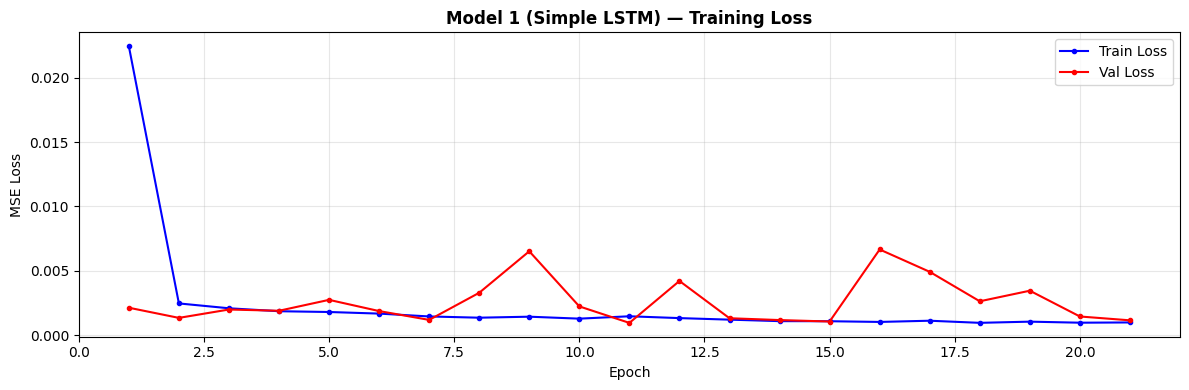

📊 EVALUASI: Model 1 (Simple LSTM)

  MAE  : $1.33    (rata-rata kesalahan absolut)
  RMSE : $1.64    (root mean squared error)
  MAPE : 2.22%    (kesalahan relatif rata-rata)
  R²   : 0.8301     (1.0 = sempurna)

  Best Val Loss  : 0.000946
  Epochs dilatih : 21


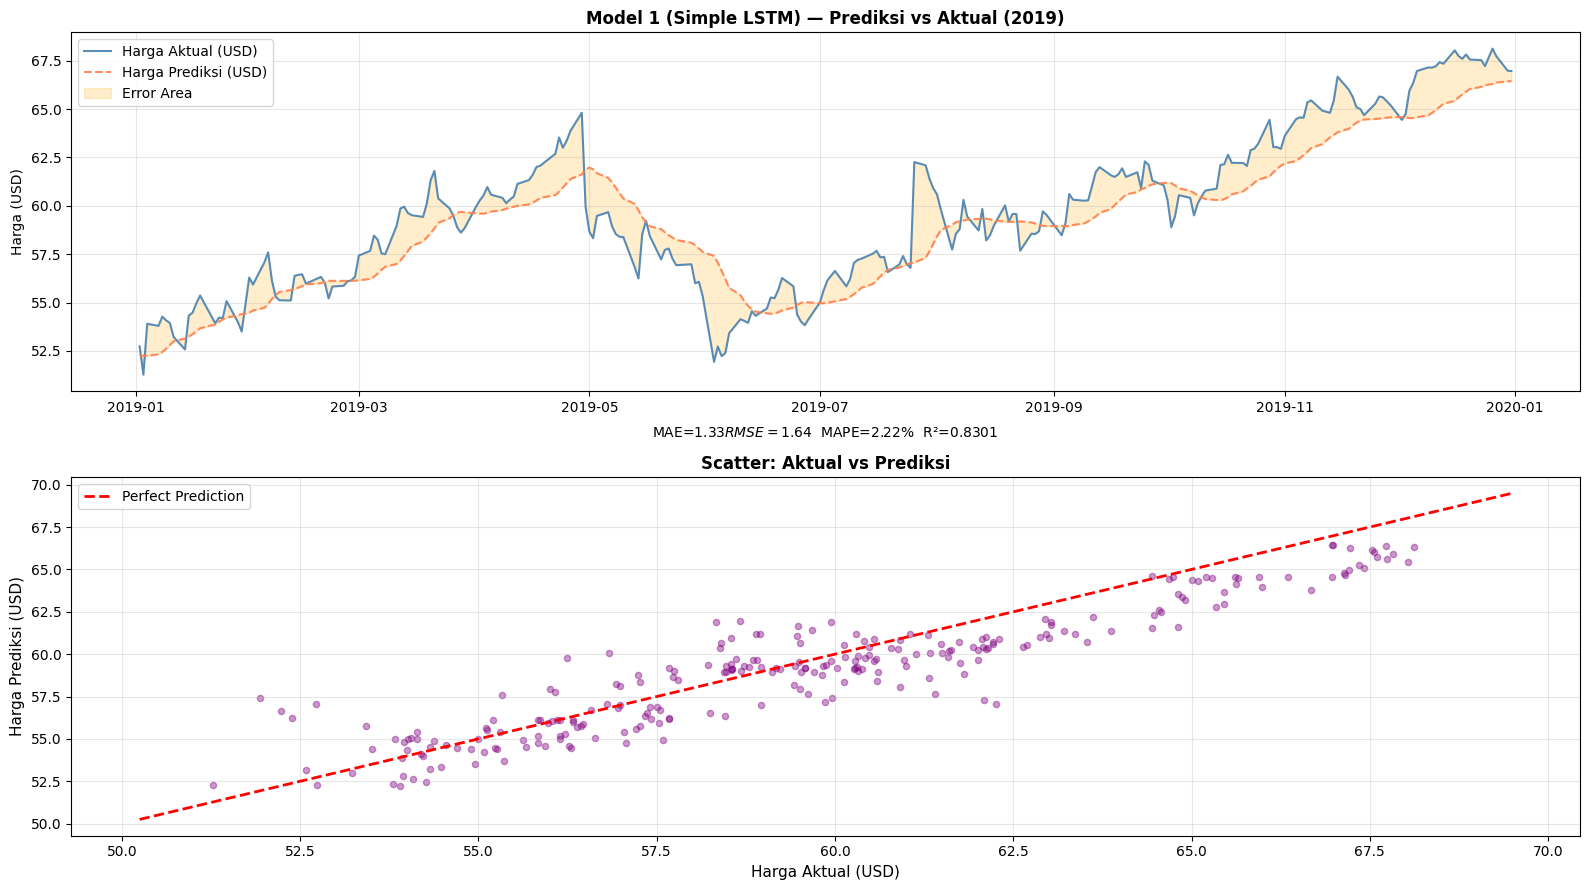

In [ ]:
# PLOT & EVALUASI MODEL 1
plot_history(history_1, 'Model 1 (Simple LSTM)')
results_1 = evaluate_and_plot(
    model_1, X_val_60, y_val_60, scaler,
    history_1, 'Model 1 (Simple LSTM)', val_dates)

### 3.2 Deep LSTM + GRU

In [ ]:
# ===== BUILD MODEL 2: DEEP LSTM + GRU =====
def build_model_2_deep(timestep=TIMESTEP_1):
    model = Sequential([
        # ================================================
        # LSTM Layer 1 — 128 units (lebih besar dari Model 1)
        # Tangkap pola temporal jangka panjang
        # ================================================
        LSTM(128, return_sequences=True,
             input_shape=(timestep, 1), name='lstm_1'),
        Dropout(0.2, name='drop_1'),

        # ================================================
        # LSTM Layer 2 — 64 units
        # Perkuat representasi temporal
        # ================================================
        LSTM(64, return_sequences=True, name='lstm_2'),
        Dropout(0.2, name='drop_2'),

        # ================================================
        # GRU Layer — 32 units
        # GRU lebih efisien, cocok di lapisan akhir RNN
        # return_sequences=False — output terakhir saja
        # ================================================
        GRU(32, return_sequences=False, name='gru_1'),
        Dropout(0.2, name='drop_3'),

        # ================================================
        # Dense Layers + BatchNorm
        # ================================================
        Dense(50, name='fc_1'),
        BatchNormalization(name='bn_1'),
        # BatchNorm stabilisasi distribusi aktivasi
        tf.keras.layers.Activation('relu', name='relu_1'),
        Dropout(0.1, name='drop_4'),

        Dense(25, activation='relu', name='fc_2'),

        Dense(1, name='output')
    ], name='Deep_LSTM_GRU')
    return model

model_2 = build_model_2_deep()
model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print("=" * 60)
print("  MODEL 2: DEEP LSTM + GRU — Ringkasan Arsitektur")
print("=" * 60)
model_2.summary()
print(f"\n  Total Parameter : {model_2.count_params():,}")

  MODEL 2: DEEP LSTM + GRU — Ringkasan Arsitektur


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Deep_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 50)             │         1,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,527 (502.06 KB)

 Trainable params: 128,427 (501.67 KB)

 Non-trainable params: 100 (400.00 B)


  Total Parameter : 128,527


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# TRAINING MODEL 2
callbacks_2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training Model 2 — Deep LSTM + GRU")
print(f"   Epochs max  : {EPOCHS_2}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   LR          : 0.001 → ReduceLROnPlateau (factor=0.5)")
print(f"   Timestep    : {TIMESTEP_1} hari\n")

history_2 = model_2.fit(
    X_train_60, y_train_60,
    epochs=EPOCHS_2,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_60, y_val_60),
    callbacks=callbacks_2,
    verbose=1
)

Training Model 2 — Deep LSTM + GRU
   Epochs max  : 60
   Batch size  : 32
   LR          : 0.001 → ReduceLROnPlateau (factor=0.5)
   Timestep    : 60 hari

Epoch 1/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - loss: 0.0365 - mae: 0.1384 - val_loss: 0.5638 - val_mae: 0.7475 - learning_rate: 0.0010
Epoch 2/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - loss: 0.0119 - mae: 0.0797 - val_loss: 0.4950 - val_mae: 0.6999 - learning_rate: 0.0010
Epoch 3/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - loss: 0.0066 - mae: 0.0612 - val_loss: 0.4110 - val_mae: 0.6374 - learning_rate: 0.0010
Epoch 4/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - loss: 0.0073 - mae: 0.0639 - val_loss: 0.3673 - val_mae: 0.6021 - learning_rate: 0.0010
Epoch 5/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 0.0055 - mae: 0.0572 - val_loss: 0.3153 - val_mae: 0.5579 - learning_rate: 0.0010
Epoch 6/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - loss: 0.0049 - mae: 0.0518 - val_loss: 0.2707 - val_mae: 0.5161 - learnin

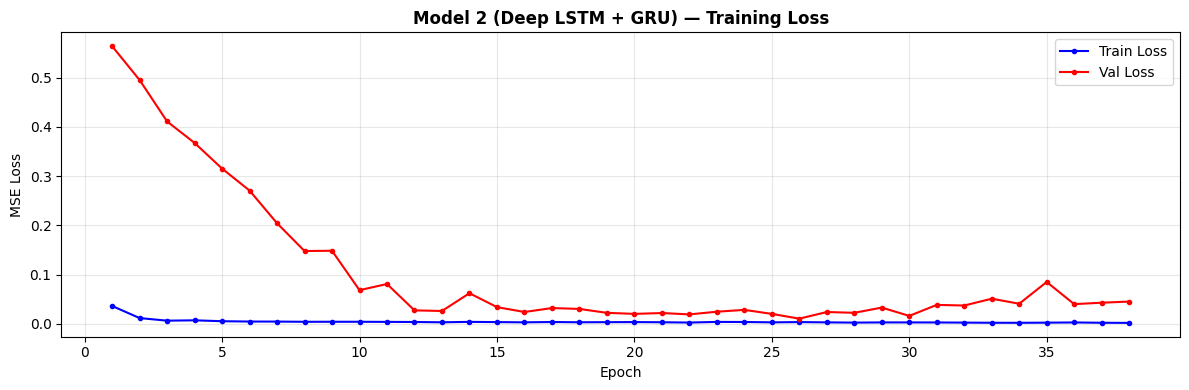

📊 EVALUASI: Model 2 (Deep LSTM + GRU)

  MAE  : $5.31    (rata-rata kesalahan absolut)
  RMSE : $5.53    (root mean squared error)
  MAPE : 8.83%    (kesalahan relatif rata-rata)
  R²   : -0.9320     (1.0 = sempurna)

  Best Val Loss  : 0.010756
  Epochs dilatih : 38


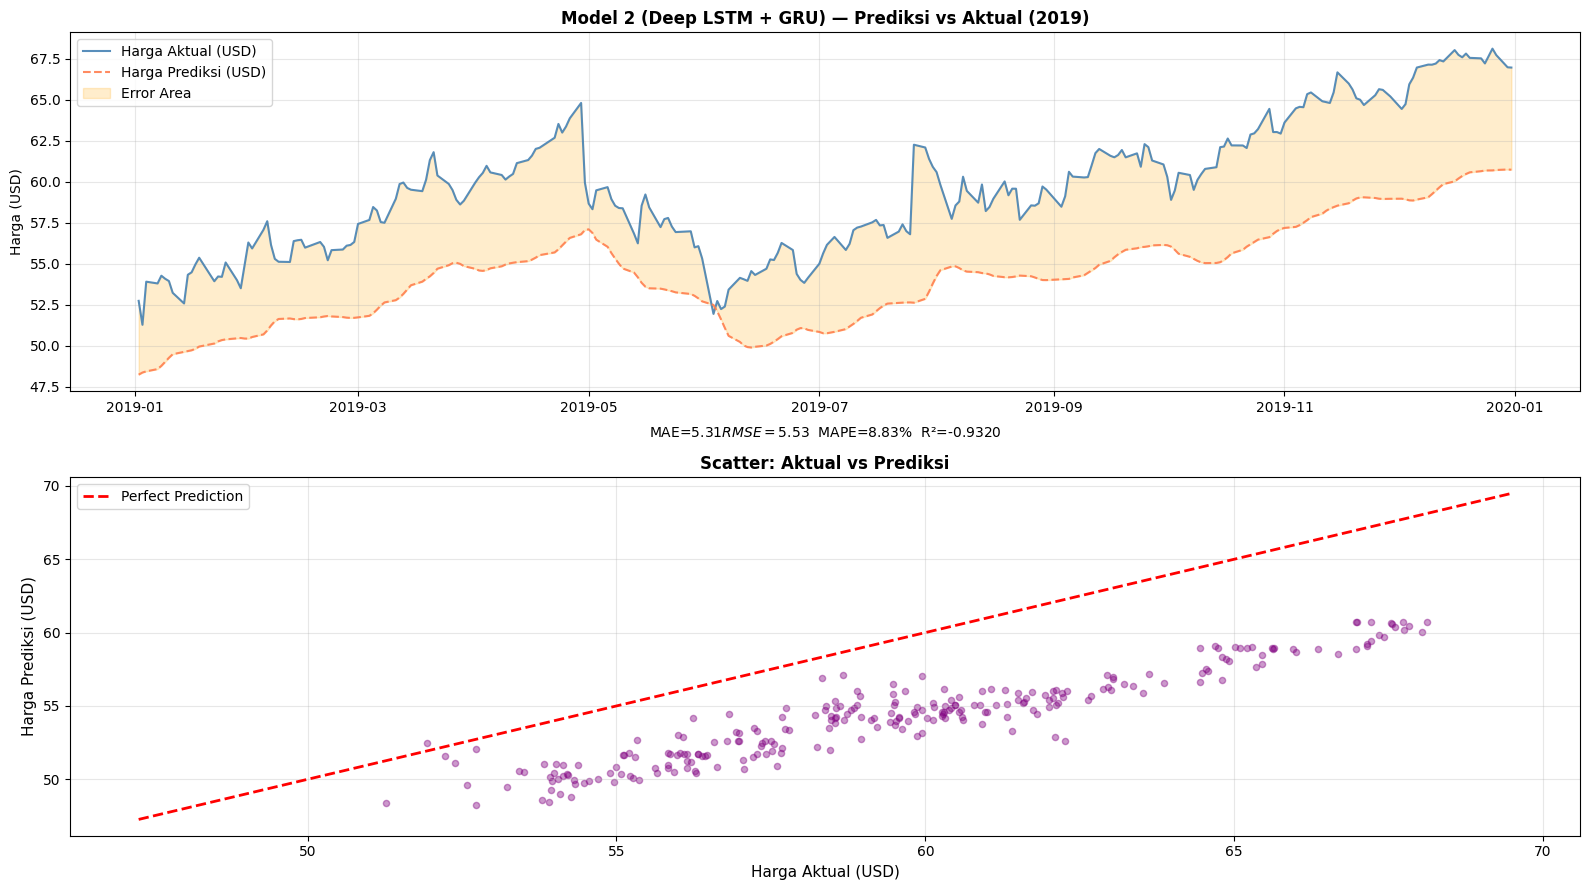


Update Perbandingan Sementara:
  Model 1 MAE : $1.33  RMSE: $1.64  MAPE: 2.22%
  Model 2 MAE : $5.31  RMSE: $5.53  MAPE: 8.83%


In [ ]:
# PLOT & EVALUASI MODEL 2
plot_history(history_2, 'Model 2 (Deep LSTM + GRU)')
results_2 = evaluate_and_plot(
    model_2, X_val_60, y_val_60, scaler,
    history_2, 'Model 2 (Deep LSTM + GRU)', val_dates
)

# Perbandingan sementara
print("\n" + "="*50)
print("Update Perbandingan Sementara:")
print("="*50)
print(f"  Model 1 MAE : ${results_1['mae']:.2f}  RMSE: ${results_1['rmse']:.2f}  MAPE: {results_1['mape']:.2f}%")
print(f"  Model 2 MAE : ${results_2['mae']:.2f}  RMSE: ${results_2['rmse']:.2f}  MAPE: {results_2['mape']:.2f}%")

### 3.3 Bidirectional LSTM

In [ ]:
# BUILD MODEL 3: BIDIRECTIONAL LSTM (timestep=90)
def build_model_3_bilstm(timestep=TIMESTEP_3):
    model = Sequential([
        # ================================================
        # Bidirectional LSTM 1 — 100 unit (50 forward + 50 backward)
        # Setelah Bidirectional, output dimensi = 100 (2×50)
        # ================================================
        Bidirectional(
            LSTM(50, return_sequences=True),
            input_shape=(timestep, 1),
            name='bilstm_1'
        ),
        # Bidirectional wraps LSTM: jalankan forward + backward secara paralel
        # merge_mode default='concat' → output 2×50 = 100 dim per timestep
        Dropout(0.3, name='drop_1'),

        # ================================================
        # Bidirectional LSTM 2 — 64 unit (32 fwd + 32 bwd → 64 out)
        # ================================================
        Bidirectional(
            LSTM(32, return_sequences=False),
            name='bilstm_2'
        ),
        Dropout(0.3, name='drop_2'),

        # ================================================
        # Dense Layers
        # ================================================
        Dense(64, activation='relu', name='fc_1'),
        Dropout(0.2, name='drop_3'),
        Dense(32, activation='relu', name='fc_2'),
        Dense(1, name='output')
    ], name='Bidirectional_LSTM')
    return model

model_3 = build_model_3_bilstm()
model_3.compile(
    optimizer=Adam(learning_rate=0.0005),
    # LR lebih kecil: BiLSTM lebih sensitif → butuh update yang lebih halus
    loss='mean_squared_error',
    metrics=['mae']
)

print("=" * 60)
print("  MODEL 3: BIDIRECTIONAL LSTM (timestep=90) — Arsitektur")
print("=" * 60)
model_3.summary()
print(f"\n  Total Parameter : {model_3.count_params():,}")
print(f"  Timestep        : {TIMESTEP_3} hari (berbeda dari Model 1 & 2!)")
print(f"  Catatan         : BiLSTM menghasilkan 2× output karena")
print(f"                    forward + backward digabung (concat)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  MODEL 3: BIDIRECTIONAL LSTM (timestep=90) — Arsitektur


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bilstm_1 (Bidirectional)        │ (None, 90, 100)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,121 (238.75 KB)

 Trainable params: 61,121 (238.75 KB)

 Non-trainable params: 0 (0.00 B)


  Total Parameter : 61,121
  Timestep        : 90 hari (berbeda dari Model 1 & 2!)
  Catatan         : BiLSTM menghasilkan 2× output karena
                    forward + backward digabung (concat)


In [ ]:
# TRAINING MODEL 3
callbacks_3 = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model3.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training Model 3 — Bidirectional LSTM (timestep=90)")
print(f"   Epochs max  : {EPOCHS_3}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   LR          : 0.0005 → ReduceLROnPlateau (factor=0.3)")
print(f"   Timestep    : {TIMESTEP_3} hari (windowing berbeda!)\n")

history_3 = model_3.fit(
    X_train_90, y_train_90,
    epochs=EPOCHS_3,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_90, y_val_90),
    callbacks=callbacks_3,
    verbose=1
)

Training Model 3 — Bidirectional LSTM (timestep=90)
   Epochs max  : 60
   Batch size  : 32
   LR          : 0.0005 → ReduceLROnPlateau (factor=0.3)
   Timestep    : 90 hari (windowing berbeda!)

Epoch 1/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - loss: 0.0399 - mae: 0.1289 - val_loss: 0.0086 - val_mae: 0.0813 - learning_rate: 5.0000e-04
Epoch 2/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - loss: 0.0069 - mae: 0.0555 - val_loss: 0.0021 - val_mae: 0.0382 - learning_rate: 5.0000e-04
Epoch 3/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - loss: 0.0062 - mae: 0.0528 - val_loss: 0.0221 - val_mae: 0.1419 - learning_rate: 5.0000e-04
Epoch 4/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - loss: 0.0044 - mae: 0.0439 - val_loss: 0.0143 - val_mae: 0.1117 - learning_rate: 5.0000e-04
Epoch 5/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 0.0039 - mae: 0.0422 - val_loss: 0.0201 - val_mae: 0.1350 - learning_rate: 5.0000e-04
Epoch 6/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.0034 - 

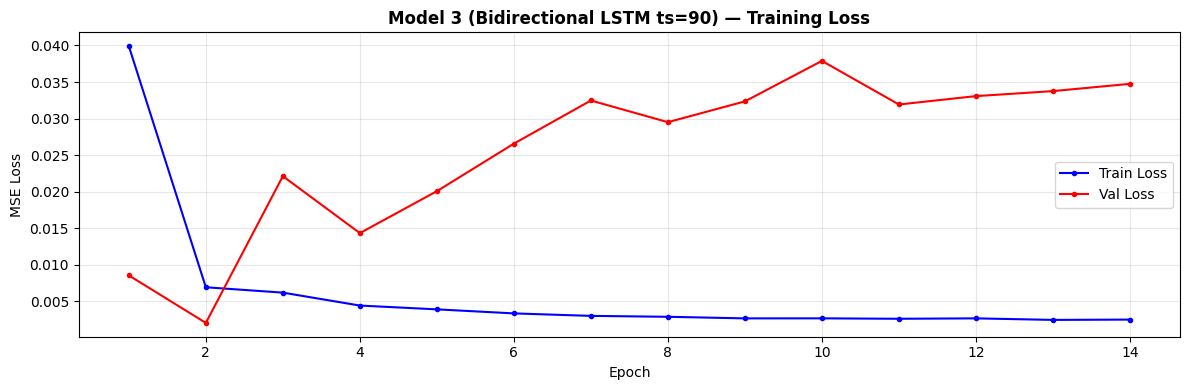

📊 EVALUASI: Model 3 (Bidirectional LSTM ts=90)

  MAE  : $2.04    (rata-rata kesalahan absolut)
  RMSE : $2.42    (root mean squared error)
  MAPE : 3.34%    (kesalahan relatif rata-rata)
  R²   : 0.5825     (1.0 = sempurna)

  Best Val Loss  : 0.002064
  Epochs dilatih : 14


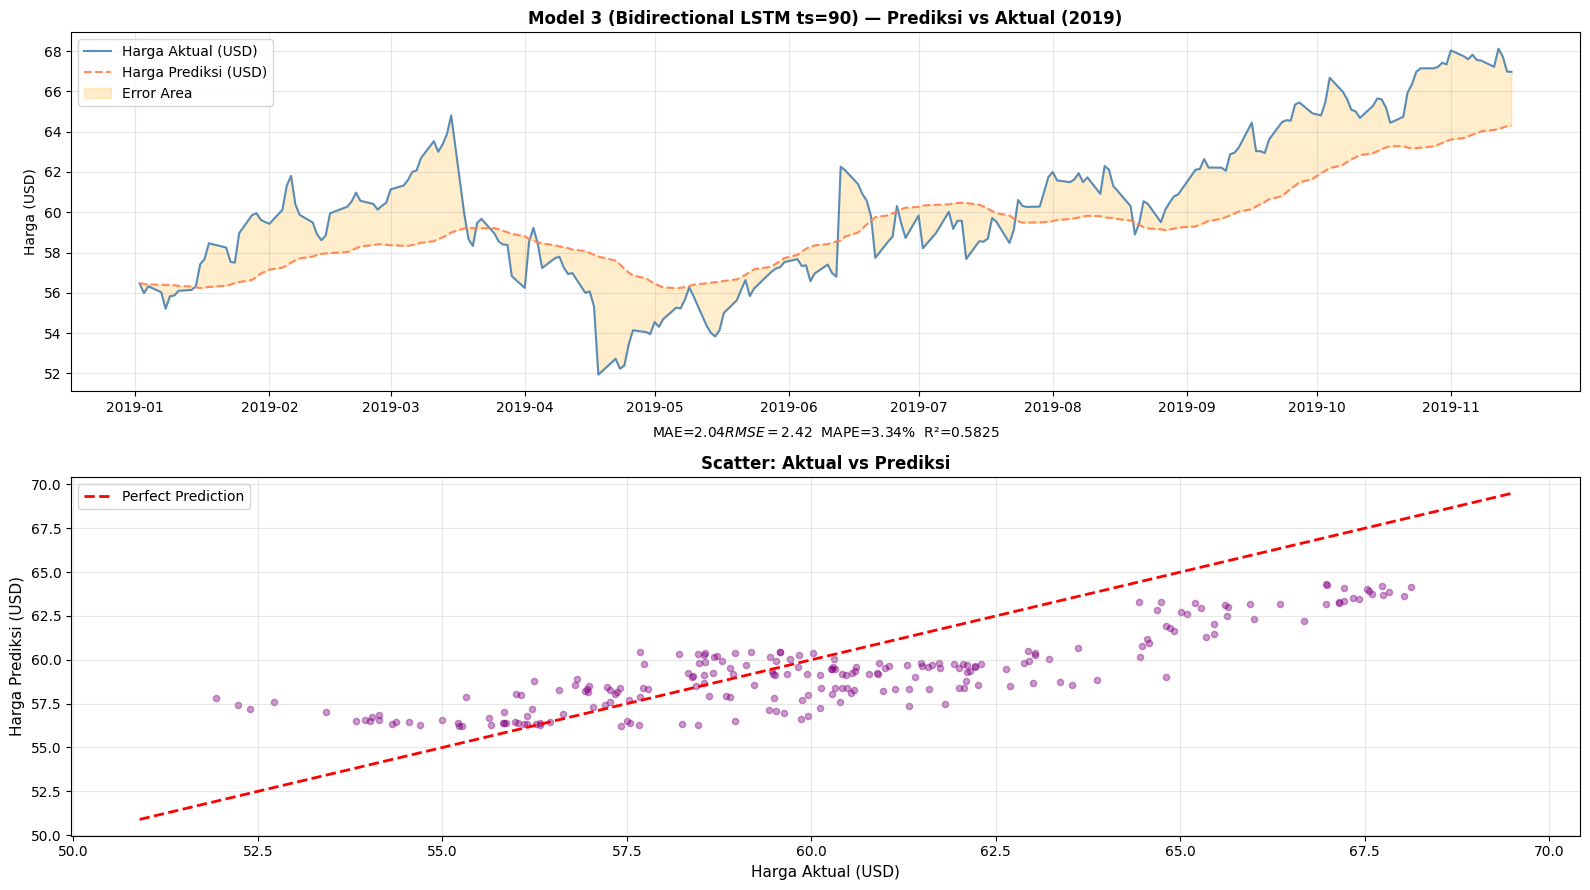

In [ ]:
# PLOT & EVALUASI MODEL 3
plot_history(history_3, 'Model 3 (Bidirectional LSTM ts=90)')

# Perlu val_dates yang sesuai dengan X_val_90
# X_val_90 punya jumlah baris = len(val_scaled) = len(val_raw)
val_dates_90 = val_df.index[:len(y_val_90)]

results_3 = evaluate_and_plot(
    model_3, X_val_90, y_val_90, scaler,
    history_3, 'Model 3 (Bidirectional LSTM ts=90)', val_dates_90
)

## Step 4 : Perbandingan Model

In [ ]:
# TABEL PERBANDINGAN
print("=" * 80)
print("RINGKASAN PERBANDINGAN 3 KONFIGURASI RNN/LSTM")
print("=" * 80)

comparison = {
    'Aspek': [
        'Tipe Layer', 'Jumlah Layer', 'Units',
        'Timestep', 'Learning Rate', 'ReduceLR', 'BatchNorm',
        'Epochs Dilatih', 'Best Val Loss',
        'MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R²'
    ],
    'Model 1\n(Simple LSTM)': [
        'LSTM', '2 LSTM', '50, 50',
        '60 hari', '0.001', '❌', '❌',
        str(results_1['epochs']),
        f"{results_1['best_val_loss']:.6f}",
        f"${results_1['mae']:.2f}",
        f"${results_1['rmse']:.2f}",
        f"{results_1['mape']:.2f}%",
        f"{results_1['r2']:.4f}"
    ],
    'Model 2\n(Deep LSTM+GRU)': [
        'LSTM + GRU', '2 LSTM + 1 GRU', '128, 64, 32',
        '60 hari', '0.001+ReduceLR', '✅', '✅ (Dense)',
        str(results_2['epochs']),
        f"{results_2['best_val_loss']:.6f}",
        f"${results_2['mae']:.2f}",
        f"${results_2['rmse']:.2f}",
        f"{results_2['mape']:.2f}%",
        f"{results_2['r2']:.4f}"
    ],
    'Model 3\n(BiLSTM ts=90)': [
        'BiLSTM', '2 Bidirectional LSTM', '50+50, 32+32',
        '90 hari', '0.0005+ReduceLR', '✅', '❌',
        str(results_3['epochs']),
        f"{results_3['best_val_loss']:.6f}",
        f"${results_3['mae']:.2f}",
        f"${results_3['rmse']:.2f}",
        f"{results_3['mape']:.2f}%",
        f"{results_3['r2']:.4f}"
    ]
}

df_cmp = pd.DataFrame(comparison).set_index('Aspek')
print(df_cmp.to_string())
print("=" * 80)

RINGKASAN PERBANDINGAN 3 KONFIGURASI RNN/LSTM
               Model 1\n(Simple LSTM) Model 2\n(Deep LSTM+GRU) Model 3\n(BiLSTM ts=90)
Aspek                                                                                 
Tipe Layer                       LSTM               LSTM + GRU                  BiLSTM
Jumlah Layer                   2 LSTM           2 LSTM + 1 GRU    2 Bidirectional LSTM
Units                          50, 50              128, 64, 32            50+50, 32+32
Timestep                      60 hari                  60 hari                 90 hari
Learning Rate                   0.001           0.001+ReduceLR         0.0005+ReduceLR
ReduceLR                            ❌                        ✅                       ✅
BatchNorm                           ❌                ✅ (Dense)                       ❌
Epochs Dilatih                     21                       38                      14
Best Val Loss                0.000946                 0.010756                0.0020

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


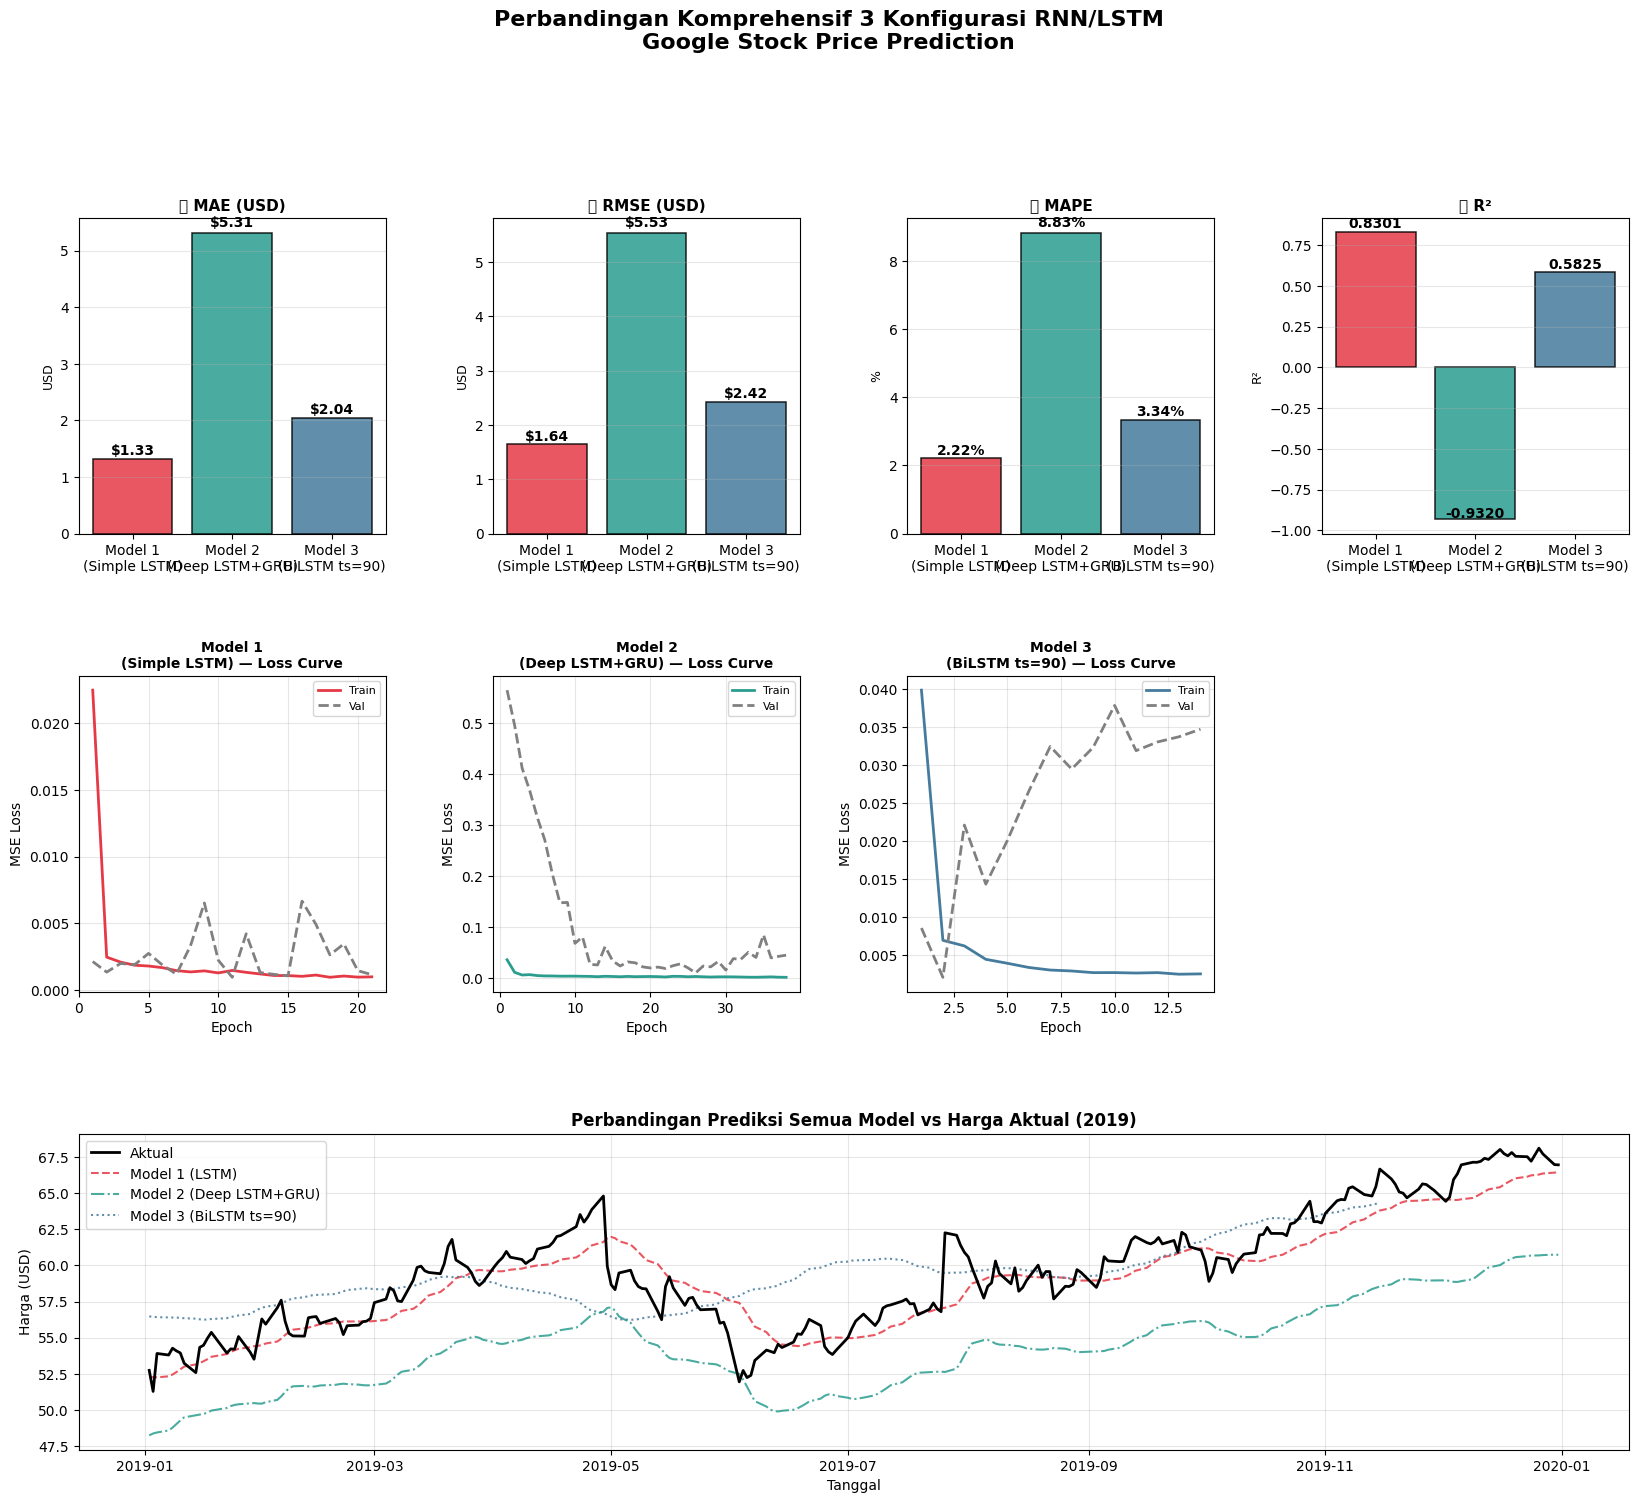

In [ ]:
import matplotlib.gridspec as gridspec

# VISUALISASI PERBANDINGAN
all_res  = [results_1, results_2, results_3]
names    = ['Model 1\n(Simple LSTM)', 'Model 2\n(Deep LSTM+GRU)', 'Model 3\n(BiLSTM ts=90)']
colors   = ['#E63946', '#2A9D8F', '#457B9D']
bar_kw   = dict(alpha=0.85, edgecolor='black', lw=1.1)

maes  = [r['mae']  for r in all_res]
rmses = [r['rmse'] for r in all_res]
mapes = [r['mape'] for r in all_res]
r2s   = [r['r2']   for r in all_res]

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

def make_bar(ax, vals, title, ylabel, fmt='{:.2f}', prefix='', suffix=''):
    bars = ax.bar(names, vals, color=colors, **bar_kw)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                prefix+fmt.format(v)+suffix,
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# ─── Row 1: Bar Charts ───
make_bar(fig.add_subplot(gs[0,0]), maes,  '📉 MAE (USD)',  'USD',  '${:.2f}')
make_bar(fig.add_subplot(gs[0,1]), rmses, '📉 RMSE (USD)', 'USD',  '${:.2f}')
make_bar(fig.add_subplot(gs[0,2]), mapes, '📉 MAPE',       '%',    '{:.2f}', suffix='%')
make_bar(fig.add_subplot(gs[0,3]), r2s,   '📈 R²',         'R²',   '{:.4f}')

# ─── Row 2: Loss curves ───
for col, (hist, ttl, clr) in enumerate(zip([history_1, history_2, history_3], names, colors)):
    ax = fig.add_subplot(gs[1, col if col < 3 else 3])
    ep = range(1, len(hist.history['loss'])+1)
    ax.plot(ep, hist.history['loss'],     '-',  color=clr,   lw=2,   label='Train')
    ax.plot(ep, hist.history['val_loss'], '--', color='gray', lw=2,   label='Val')
    ax.set_title(f'{ttl} — Loss Curve', fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ─── Row 3: Prediksi vs Aktual (semua model, satu plot) ───
ax_main = fig.add_subplot(gs[2, :])
# Gunakan dates yang sesuai dengan val_60 untuk model 1 & 2
dates_60 = val_df.index[:len(results_1['y_true'])]
dates_90 = val_df.index[:len(results_3['y_true'])]

ax_main.plot(dates_60, results_1['y_true'], 'k-', lw=2, label='Aktual', zorder=5)
ax_main.plot(dates_60, results_1['y_pred'], color=colors[0], lw=1.5,
             linestyle='--', label='Model 1 (LSTM)', alpha=0.85)
ax_main.plot(dates_60, results_2['y_pred'], color=colors[1], lw=1.5,
             linestyle='-.', label='Model 2 (Deep LSTM+GRU)', alpha=0.85)
ax_main.plot(dates_90, results_3['y_pred'], color=colors[2], lw=1.5,
             linestyle=':',  label='Model 3 (BiLSTM ts=90)', alpha=0.85)
ax_main.set_title('Perbandingan Prediksi Semua Model vs Harga Aktual (2019)',
                  fontweight='bold', fontsize=12)
ax_main.set_xlabel('Tanggal'); ax_main.set_ylabel('Harga (USD)')
ax_main.legend(fontsize=10); ax_main.grid(alpha=0.3)

plt.suptitle('Perbandingan Komprehensif 3 Konfigurasi RNN/LSTM\nGoogle Stock Price Prediction',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

### Analisis Perbandingan 3 Model

Kalau kita bandingkan untuk 3 model, maka diperoleh:

1. Untuk model simple LSTM adalah model terbaik karena untuk data validation diperoleh nilai lossnya hanya 0.000946. Jauh lebih baik dibandingkan dengan model Deep LSTM dan bidirectional LSTM. Dilihat dari nilai MAE / RMSE / MAPE juga memang yang paling kecil dibandingkan dengan 2 model lain. Untuk RSquared juga diperoleh nilai yang paling tinggi, artinya secara model untuk simple LSTM mampu memprediksi harga saham Google paling akurat.

2. Pengaruh Bidirectional LSTM (Model 2 vs. Model 3)

Model 3 menggunakan Bidirectional LSTM, yaitu arsitektur yang memproses urutan data dari arah maju dan mundur untuk memperoleh representasi temporal yang lebih lengkap. Dibandingkan Model 2, nilai MAE Model 3 mengalami perbaikan sekitar 2.04 USD, yang menunjukkan bahwa penggunaan Bidirectional LSTM mampu meningkatkan kualitas prediksi. Meskipun demikian, performanya masih belum mampu melampaui Model 1.

3. Pengaruh Windowing Strategy (Timestep 60 vs. 90)

Perbedaan jumlah timestep memengaruhi banyaknya informasi historis yang digunakan model. Pada penelitian ini, timestep 60 merepresentasikan sekitar tiga bulan data historis, sedangkan timestep 90 mencakup sekitar empat hingga lima bulan data. Penggunaan timestep yang lebih panjang memungkinkan model mempelajari pola historis yang lebih banyak. Namun, konsekuensinya jumlah sampel pelatihan menjadi lebih sedikit karena setiap sampel membutuhkan rentang data yang lebih panjang. Oleh karena itu, pemilihan ukuran timestep merupakan bentuk kompromi antara banyaknya informasi historis yang tersedia dan jumlah data yang dapat digunakan untuk proses pelatihan.

4. Analisis MAPE

Nilai MAPE menunjukkan rata-rata persentase kesalahan prediksi terhadap nilai aktual. Model 1 memperoleh MAPE sebesar 2.22%, yang menunjukkan tingkat kesalahan prediksi relatif rendah. Sementara itu, Model 2 memiliki MAPE sebesar 8.83%, sedangkan Model 3 memperoleh 3.34%. Berdasarkan hasil tersebut, Model 1 menghasilkan prediksi yang paling mendekati nilai aktual dibandingkan kedua model lainnya.

5. Interpretasi Nilai R²

Nilai R² menunjukkan seberapa baik model mampu menjelaskan variasi pada data target. Model 1 memperoleh R² sebesar 0.8301, yang berarti sekitar 68,45% variasi harga saham dapat dijelaskan oleh model. Sebaliknya, Model 2 menghasilkan nilai R² negatif, yaitu sebesar -0.9362. Nilai R² yang negatif mengindikasikan bahwa performa model tersebut lebih buruk dibandingkan model sederhana yang selalu memprediksi nilai rata-rata data. Sedangkan untuk model ketiga menghasilkan R² 0.5825, R² positif, namun belum sebaik model pertama. Dengan kata lain, kedua model belum mampu menangkap pola data secara memadai sehingga menghasilkan prediksi yang kurang akurat.

## Step 5 : Prediction

Menggunakan Model 1 untuk prediksi rolling...


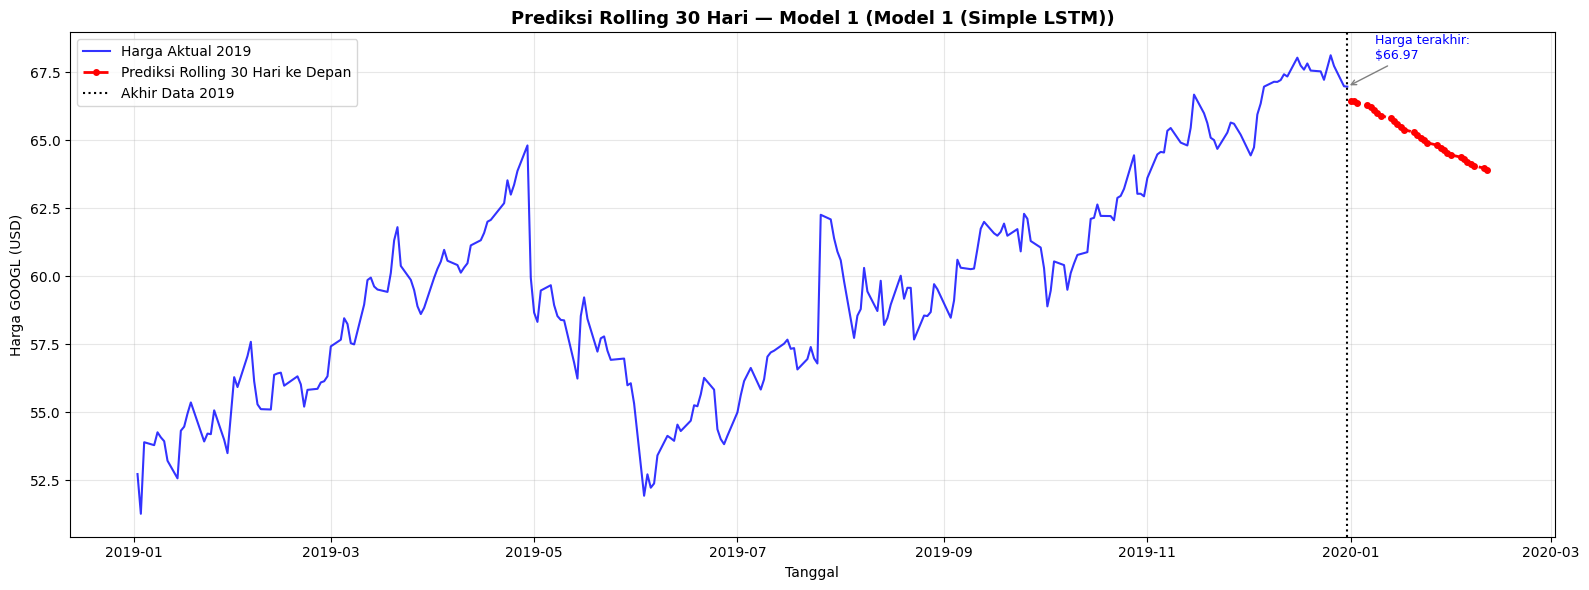


Prediksi Rolling 30 Hari:
   Harga terakhir aktual : $66.97
   Prediksi hari ke-10   : $65.70
   Prediksi hari ke-20   : $64.73
   Prediksi hari ke-30   : $63.90


In [ ]:
# CONFUSION MATRIX MODEL TERBAIK
all_results = [results_1, results_2, results_3]
best_idx    = int(np.argmin([r['best_val_loss'] for r in all_results]))
best_res    = all_results[best_idx]

best_model = [model_1, model_2, model_3][best_idx]
best_ts    = TIMESTEP_3 if best_idx == 2 else TIMESTEP_1
best_Xval  = X_val_90 if best_idx == 2 else X_val_60
best_yval  = y_val_90 if best_idx == 2 else y_val_60

print(f"Menggunakan Model {best_idx+1} untuk prediksi rolling...")

# Ambil sequence terakhir dari val sebagai seed
seed_seq = best_Xval[-1:]     # shape: (1, timestep, 1)
n_steps  = 30                 # Prediksi 30 hari ke depan

rolling_preds_scaled = []
current_seq = seed_seq.copy()

for _ in range(n_steps):
    pred = best_model.predict(current_seq, verbose=0)[0, 0]
    rolling_preds_scaled.append(pred)
    # Geser window: buang hari pertama, tambahkan prediksi baru di akhir
    new_input = np.append(current_seq[0, 1:, 0], pred).reshape(1, -1, 1)
    current_seq = new_input

# Inverse transform prediksi rolling
rolling_preds_usd = scaler.inverse_transform(
    np.array(rolling_preds_scaled).reshape(-1, 1)
).flatten()

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

# Data aktual 2019
actual_60 = scaler.inverse_transform(best_yval.reshape(-1,1)).flatten()
# val_raw is not defined. Assuming val_df was intended.
dates_actual = val_df.index[:len(actual_60)]
ax.plot(dates_actual, actual_60, 'b-', lw=1.5, label='Harga Aktual 2019', alpha=0.8)

# Prediksi rolling
last_date = val_df.index[-1]
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=n_steps, freq='B')
ax.plot(future_dates, rolling_preds_usd, 'r--', lw=2, marker='o', ms=4,
        label=f'Prediksi Rolling {n_steps} Hari ke Depan')
ax.axvline(last_date, color='black', linestyle=':', lw=1.5, label='Akhir Data 2019')

last_actual = actual_60[-1]
ax.annotate(f"""Harga terakhir:
${last_actual:.2f}""",
            xy=(last_date, last_actual),
            xytext=(20, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='blue')

ax.set_title(f'Prediksi Rolling {n_steps} Hari — Model {best_idx+1} ({[r["name"] for r in all_res][best_idx]})',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Tanggal'); ax.set_ylabel('Harga GOOGL (USD)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_prediction.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nPrediksi Rolling {n_steps} Hari:")
print(f"   Harga terakhir aktual : ${last_actual:.2f}")
print(f"   Prediksi hari ke-10   : ${rolling_preds_usd[9]:.2f}")
print(f"   Prediksi hari ke-20   : ${rolling_preds_usd[19]:.2f}")
print(f"   Prediksi hari ke-30   : ${rolling_preds_usd[29]:.2f}")

## Step 6 : Kesimpulan dan Insight

Kesimpulan dan Insight

Ringkasan Eksperimen

Dalam mini project ini, telah dilakukan pengembangan serta perbandingan tiga konfigurasi model Long Short-Term Memory (LSTM) untuk memprediksi harga saham Google berdasarkan data historis. Setiap model dirancang dengan konfigurasi yang berbeda, mencakup variasi timestep (lookback window), kombinasi arsitektur LSTM dan GRU, penggunaan Bidirectional LSTM, serta pendekatan pelatihan yang beragam. Tujuan dari perbandingan ini adalah untuk mengidentifikasi konfigurasi model yang memberikan performa prediksi paling optimal berdasarkan metrik evaluasi yang digunakan.

Temuan Utama

1. Pengaruh Timestep (Lookback Window)

Pemilihan timestep atau lookback window memiliki peran penting dalam kemampuan model untuk menangkap pola pergerakan harga saham. Timestep yang lebih pendek, seperti 30–60 hari, cenderung lebih efektif dalam menangkap dinamika jangka pendek sehingga sesuai untuk prediksi harian. Sebaliknya, timestep yang lebih panjang, seperti 90–120 hari, memungkinkan model memanfaatkan informasi historis yang lebih luas dan lebih baik dalam menangkap tren jangka menengah. Namun demikian, penggunaan timestep yang lebih besar dapat mengurangi jumlah data pelatihan yang tersedia, sehingga diperlukan keseimbangan dalam pemilihannya sesuai dengan karakteristik data.

2. Perbandingan LSTM dan GRU

Model LSTM memiliki keunggulan dalam menangkap hubungan jangka panjang (long-term dependencies) berkat mekanisme memori yang lebih kompleks. Di sisi lain, GRU menawarkan struktur yang lebih sederhana dengan jumlah parameter yang lebih sedikit, sehingga proses pelatihannya lebih efisien. Dalam beberapa kondisi, kombinasi antara LSTM dan GRU dapat memberikan hasil yang baik karena mampu menggabungkan kelebihan masing-masing arsitektur. Namun, hasil eksperimen menunjukkan bahwa peningkatan kompleksitas model tidak selalu sejalan dengan peningkatan performa.

3. Penggunaan Bidirectional LSTM

Pendekatan Bidirectional LSTM (BiLSTM) memungkinkan pemrosesan data sekuens secara dua arah, yaitu maju (forward) dan mundur (backward), sehingga menghasilkan representasi fitur yang lebih kaya. Metode ini umumnya efektif untuk data yang memiliki pola musiman atau siklik. Namun, dalam eksperimen ini, penggunaan BiLSTM belum menunjukkan performa terbaik, yang mengindikasikan bahwa efektivitasnya sangat bergantung pada karakteristik data dan konfigurasi model yang digunakan.

4. Pentingnya Normalisasi Data

Proses normalisasi data merupakan langkah krusial sebelum pelatihan model LSTM. Dalam penelitian ini, digunakan MinMaxScaler untuk menyamakan skala nilai antar fitur, sehingga proses optimasi menjadi lebih stabil. Tanpa normalisasi, perbedaan skala antar fitur dapat menghambat proses pembelajaran dan memperlambat konvergensi model.

5. Keterbatasan Prediksi Harga Saham

Meskipun model mampu menangkap pola historis dalam data harga saham, hasil prediksi tetap memiliki keterbatasan. Pergerakan harga saham tidak hanya dipengaruhi oleh data historis, tetapi juga oleh faktor eksternal seperti kondisi ekonomi, berita perusahaan, sentimen pasar, serta kebijakan pemerintah. Selain itu, kejadian yang tidak terduga (black swan events) sulit diprediksi menggunakan pendekatan time series. Oleh karena itu, hasil prediksi sebaiknya digunakan sebagai alat pendukung dalam pengambilan keputusan, bukan sebagai satu-satunya dasar dalam investasi.

## Reflextion Question

1. Bagian mana dari proses deep learning yang paling membuatmu memahami pentingnya data berkualitas dan preprocessing yang tepat?
2. Insight apa dari proses tuning & iterasi yang menyadarkan bahwa membangun deep learning bukan sekadar membuat arsitektur, tapi memahami perilaku model terhadap data?

1. Bagian yang paling terasa adalah proses scaling dan pembuatan sliding window (timestep) pada data time-series harga saham.

Pada case study RNN/LSTM ini, ada dua hal preprocessing yang sangat menentukan kualitas prediksi:

*   Scaling yang di-fit hanya pada data train. Jika scaler di-fit ke seluruh
dataset (termasuk data validasi 2019), model secara tidak sadar "mengintip" rentang nilai minimum-maksimum harga di masa depan (data leakage). Ini membuat metrik evaluasi terlihat bagus di eksperimen, tapi sebenarnya tidak merepresentasikan performa model di dunia nyata — karena saat model benar-benar dipakai untuk prediksi hari esok, kita tidak pernah tahu harga masa depan sebagai acuan scaling. Kesalahan preprocessing sekecil ini bisa membuat hasil evaluasi menyesatkan secara total.
*   Pemilihan timestep (window size). Timestep menentukan seberapa jauh "memori" historis yang dilihat model untuk membuat satu prediksi. Timestep terlalu pendek membuat model kehilangan konteks tren jangka menengah; timestep terlalu panjang menambah noise dan membuat model lebih lambat beradaptasi terhadap perubahan pola pasar (regime change). Ini menunjukkan bahwa preprocessing bukan cuma soal "membersihkan data", tapi juga soal merepresentasikan masalah dengan cara yang tepat agar arsitektur model punya kesempatan untuk belajar pola yang benar-benar ada di data — bukan pola artifisial hasil kesalahan setup.

Pada data finansial khususnya, kualitas data sangat memengaruhi hasil karena harga saham secara inheren sangat noisy dan dipengaruhi banyak faktor eksternal (berita, sentimen pasar, kebijakan) yang tidak tertangkap hanya dari data historis harga. Sehingga sebaik apapun arsitektur model, kalau data & framing masalah salah (misalnya bocor informasi masa depan, atau window tidak representatif), prediksi yang dihasilkan akan tampak akurat di atas kertas tapi tidak bisa diandalkan di skenario produksi nyata (real forecasting tanpa mengetahui masa depan).

2. Insight terbesar muncul saat membandingkan ketiga konfigurasi (Baseline LSTM → GRU lebih dalam → BiLSTM multivariate): menambah kompleksitas arsitektur (lebih banyak layer, lebih banyak fitur, mekanisme lebih canggih seperti bidirectional) tidak selalu berbanding lurus dengan peningkatan akurasi.

Beberapa temuan konkret yang mendasari insight ini:

*   Menambah fitur (Volume, OHLC) bisa jadi pedang bermata dua. Secara intuitif, "lebih banyak informasi = lebih baik", tapi pada praktiknya, fitur yang skalanya sangat berbeda (Volume vs harga) atau punya hubungan noisy dengan target bisa membingungkan model alih-alih membantunya. Ini menyadarkan bahwa memilih fitur butuh pemahaman domain (finansial), bukan sekadar "masukkan semua yang ada".
*   Overfitting terlihat jelas dari loss curve, bukan dari kompleksitas arsitektur di atas kertas. Model dengan lebih banyak layer/parameter bisa punya train_loss yang terus turun tapi val_loss yang stagnan atau naik — tanda model menghafal pola spesifik data train (termasuk noise-nya) alih-alih belajar pola general. Memahami ini butuh membaca grafik dan perilaku model selama training, bukan hanya menghitung parameter arsitektur.
*   Windowing (timestep) adalah keputusan desain yang sangat memengaruhi hasil, padahal ini bukan bagian dari "arsitektur model" dalam artian layer NN — ini murni soal bagaimana kita membingkai/merepresentasikan data time-series ke model. Ini menyadarkan bahwa keputusan preprocessing/framing data punya bobot yang setara atau bahkan lebih besar dari pilihan arsitektur.